<div style="border: 2px solid black; padding: 10px 0; ">
    <p style="color:#002395; font-size:40px; font-weight:bold; text-align:center; margin: 0 0 0 0;">Projet Data Mining IIT 2025/2026</p>
    <p style="color:#000; font-size:25px; text-align:center;"><b style = "color:#87CEEB; font-weight:bold;">Sujet : </b>Prédiction automatique des sinistres habitation
    </p>
</div>
<br>
<br>


***Importation des bibliothèques***

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore",category=FutureWarning)
from IPython.display import display

from scipy.stats import chi2_contingency, spearmanr
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler,OneHotEncoder ,LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import cross_val_score,GridSearchCV,HalvingGridSearchCV

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.metrics import f1_score, roc_auc_score

**<span style="color:blue;">LECTURE DU DATASET</span>**

In [91]:
train=pd.read_excel("insurance.xlsx" ,sheet_name='train')
test=pd.read_excel("insurance.xlsx" ,sheet_name='test')
train

,policy_id,year,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,risk_score,Geo_Code,claim
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,H13501,2012.0,1.0,1.0,N/V,V,U,1240.0,Wood-framed,without,NaN,75117,non
3,H14962,2012.0,1.0,0.0,N/V,V,U,900.0,Non-combustible,without,NaN,62916,non
4,H17755,2013.0,1.0,1.0,V/N,O,R,4984.0,Non-combustible,4,NaN,31149,oui
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5009,H13682,2013.0,1.0,0.0,N/V,V,U,550.0,Ordinary,without,NaN,33063,oui
5010,H18342,2012.0,0.5,0.0,V/N,O,R,1000.0,Fire-resistive,4,NaN,13004,non
5011,H16892,2015.0,1.0,1.0,V/N,O,R,480.0,Ordinary,3,NaN,94059,non
5012,H18805,2012.0,0.5,0.0,V/N,O,R,536.0,Fire-resistive,4,NaN,74243,non


***EDA & Data preprocessing***

**<span style="color:blue;">ANALYSE EXPLORATOIRE DES DONNÉES</span>**

In [92]:
train.describe(include='all')

,policy_id,year,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,risk_score,Geo_Code,claim
count,5012,5012.000000,5012.000000,5012.000000,5012,5008,5012,4935.000000,5012,5012,0.0,4939,5012
unique,5012,NaN,NaN,NaN,4,2,2,NaN,4,11,NaN,1115,2
top,H18228,NaN,NaN,NaN,V/N,O,R,NaN,Non-combustible,without,NaN,6088,non
freq,1,NaN,NaN,NaN,2530,2532,2537,NaN,2310,2476,NaN,102,3886
mean,NaN,2013.660215,0.869713,0.301077,NaN,NaN,NaN,1876.898683,NaN,NaN,NaN,NaN,NaN
std,NaN,1.383134,0.219496,0.458772,NaN,NaN,NaN,2267.277397,NaN,NaN,NaN,NaN,NaN
min,NaN,2012.000000,0.500000,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,2012.000000,0.500000,0.000000,NaN,NaN,NaN,520.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,2013.000000,1.000000,0.000000,NaN,NaN,NaN,1067.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,2015.000000,1.000000,1.000000,NaN,NaN,NaN,2280.000000,NaN,NaN,NaN,NaN,NaN


claim
non    3886
oui    1126
Name: count, dtype: int64


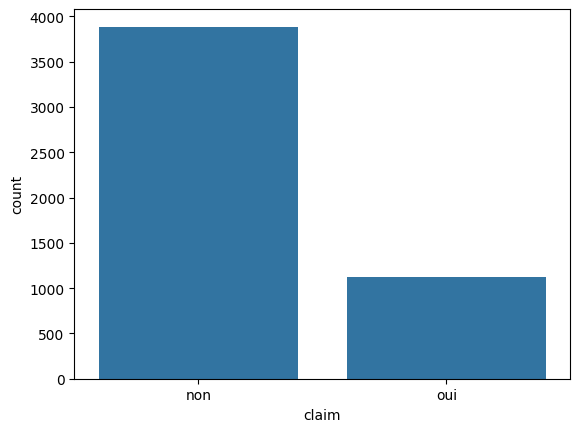

In [93]:
plt.figure()
sns.countplot(train, x="claim")
print(train['claim'].value_counts())

In [94]:
train.isna().sum()

policy_id                    2
year                         2
coverage_period              2
is_residential               2
is_finished_and_fenced       2
has_garden                   6
locality                     2
area_m2                     79
structure_type               2
window_count                 2
risk_score                5014
Geo_Code                    75
claim                        2
dtype: int64

In [95]:
train.shape

(5014, 13)

In [96]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5014 entries, 0 to 5013
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   policy_id               5012 non-null   object 
 1   year                    5012 non-null   float64
 2   coverage_period         5012 non-null   float64
 3   is_residential          5012 non-null   float64
 4   is_finished_and_fenced  5012 non-null   object 
 5   has_garden              5008 non-null   object 
 6   locality                5012 non-null   object 
 7   area_m2                 4935 non-null   float64
 8   structure_type          5012 non-null   object 
 9   window_count            5012 non-null   object 
 10  risk_score              0 non-null      float64
 11  Geo_Code                4939 non-null   object 
 12  claim                   5012 non-null   object 
dtypes: float64(5), object(8)
memory usage: 509.4+ KB


In [97]:
train["claim"].value_counts()

claim
non    3886
oui    1126
Name: count, dtype: int64

claim
non    3886
oui    1126
Name: count, dtype: int64


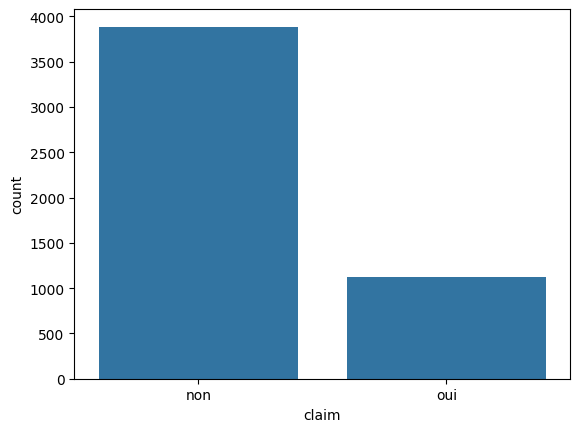

In [98]:
plt.figure()
sns.countplot(train, x="claim")
print(train['claim'].value_counts())

**<span style="color:blue;">TRAITEMENT DES NANS</span>**

In [99]:
def supprimer_colonnes(df, colonnes):
    return df.drop(columns=colonnes, errors='ignore')

In [100]:
train=supprimer_colonnes(train, ['policy_id','risk_score'])
test=supprimer_colonnes(test,['policy_id','risk_score'])

In [101]:
train.dropna(how="all",inplace=True,ignore_index=True)
test.dropna(how="all",inplace=True,ignore_index=True)

In [102]:
train=train.dropna(subset=["has_garden"],how="any",ignore_index=True)
test=test.dropna(subset=["has_garden"],how="any",ignore_index=True)


In [103]:
l_num=list(train.select_dtypes(include="number"))   

l_discret= list(train.select_dtypes(include="object")) 



print("l_num=", l_num)
print("l_dis=", l_discret)

l_num= ['year', 'coverage_period', 'is_residential', 'area_m2']
l_dis= ['is_finished_and_fenced', 'has_garden', 'locality', 'structure_type', 'window_count', 'Geo_Code', 'claim']


In [104]:
l_discret=l_num[:3]+l_discret
l_num=l_num[3:]
print("l_num=", l_num)
print("l_dis=", l_discret)

l_num= ['area_m2']
l_dis= ['year', 'coverage_period', 'is_residential', 'is_finished_and_fenced', 'has_garden', 'locality', 'structure_type', 'window_count', 'Geo_Code', 'claim']


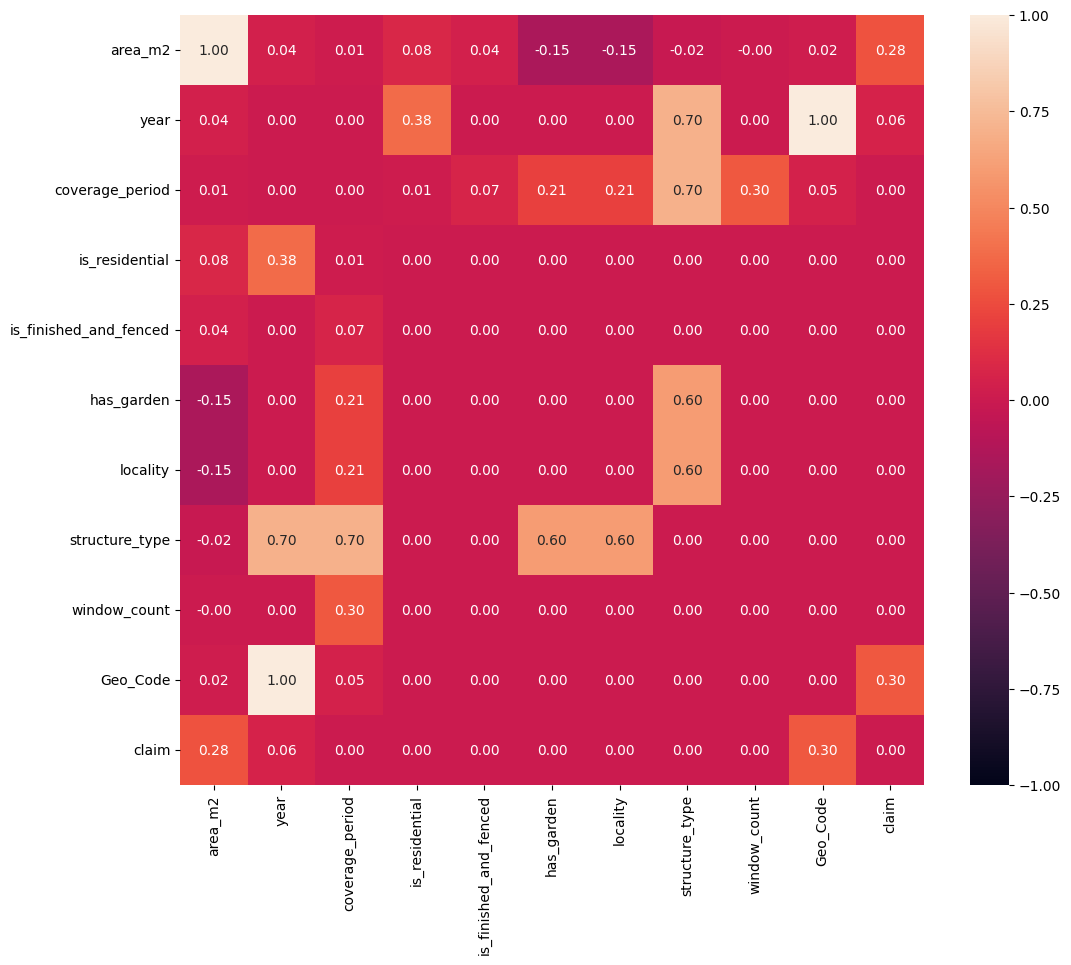

In [105]:
def compute_correlation(df, l_num, l_discret):
    cols = l_num + l_discret
    n = len(cols)
    corr_matrix = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

    for i in range(n):
        for j in range(i, n):
            col1, col2 = cols[i], cols[j]

            if col1 in l_discret and col2 in l_discret:
                
                contingency_table = pd.crosstab(df[col1], df[col2])
                _, corr, _, _ = chi2_contingency(contingency_table)
                
            else:
                
                corr, _ = spearmanr(df[col1], df[col2])

            corr_matrix.loc[col1, col2] = np.round(corr,2)
            corr_matrix.loc[col2, col1] = np.round(corr,2)  

    return corr_matrix

plt.figure(figsize=(12, 10))
sns.heatmap(compute_correlation(train.dropna(), l_num, l_discret), vmax=1, vmin=-1, annot=True, fmt=".2f")
plt.show()

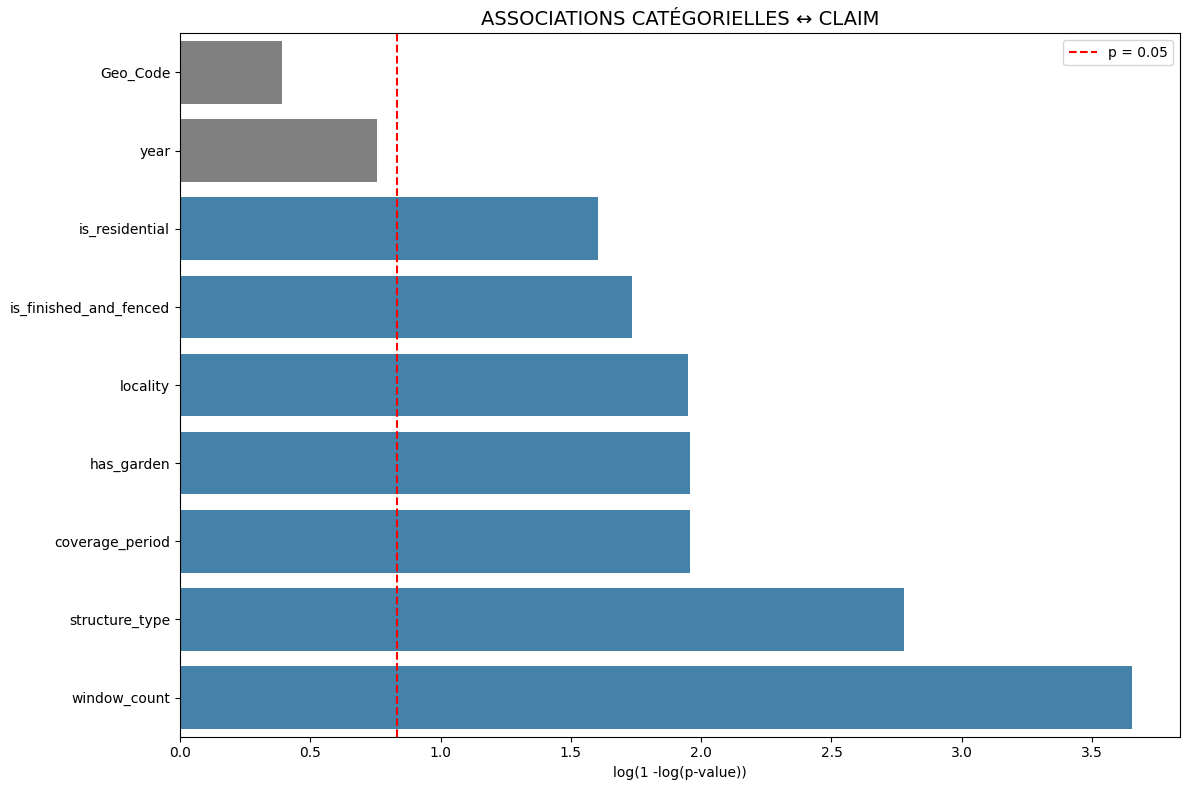

In [106]:

def plot_categorical_associations(df, target, figsize=(12, 8)):

    p_values = {}

    # --- Sélection des variables catégorielles ---
    categorical_cols = l_discret
    if target in categorical_cols:
        categorical_cols.remove(target)

    # --- Test du Chi-deux pour chaque variable ---
    for col in categorical_cols:
        contingency = pd.crosstab(df[col], df[target])
        chi2, p, dof, expected = chi2_contingency(contingency)
        p_values[col] = p

    # Convertir en DataFrame
    results = pd.DataFrame({
        "Variable": list(p_values.keys()),
        "log(1 -log(p-value))": [np.log(1 + -np.log10(v)) for v in p_values.values()]
    }).sort_values("log(1 -log(p-value))")

    # Définir seuil p = 0.05
    p_threshold = np.log(1 - np.log10(0.05))

    # --- Plot ---
    plt.figure(figsize=figsize)
    colors = ["#3385BB" if x > p_threshold else "gray" for x in results["log(1 -log(p-value))"]]

    sns.barplot(
        data=results,
        x="log(1 -log(p-value))",
        y="Variable",
        palette=colors
    )

    # Ligne verticale seuil p=0.05
    plt.axvline(p_threshold, color="red", linestyle="--", label="p = 0.05")

    # Titre et labels
    plt.title("ASSOCIATIONS CATÉGORIELLES ↔ CLAIM", fontsize=14)
    plt.xlabel("log(1 -log(p-value))")
    plt.ylabel("")

    plt.legend()
    plt.tight_layout()
    plt.show()
plot_categorical_associations(train, target="claim")

In [107]:
#categorie /categorie ::::claim/les categories 
#on enleve year et geo code car ils sont categorielles
#donc on enleve les categorielles qui ont valeur >0.05 selon chi carré

In [108]:
train =supprimer_colonnes(train, ["Geo_Code","year"])
test =supprimer_colonnes(test, ["Geo_Code","year"])
l_discret.remove('Geo_Code')
l_discret.remove('year')



In [109]:
train.isna().sum()

coverage_period            0
is_residential             0
is_finished_and_fenced     0
has_garden                 0
locality                   0
area_m2                   77
structure_type             0
window_count               0
claim                      0
dtype: int64

**<span style="color:blue;">VISUALISATION ET TRAITEMENT DE NANS ET OUTLIERS DE 'area_m2'</span>**

<Axes: ylabel='area_m2'>

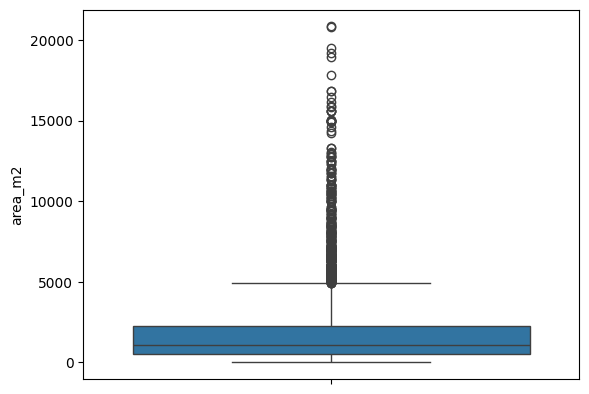

In [110]:
sns.boxplot(train['area_m2'])


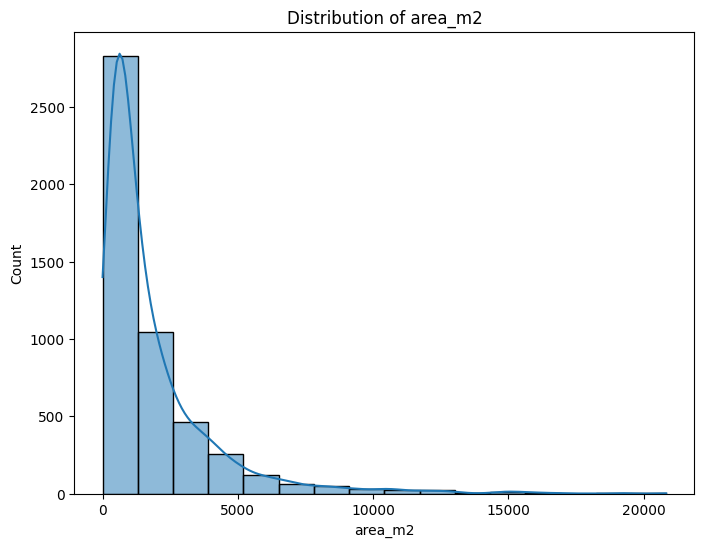

In [111]:
def plot_kde(df):
    numeric_cols = l_num
    
    for col in numeric_cols:
        plt.figure(figsize=(8, 6))
        sns.histplot(data=df,bins=16, x=col, kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()


plot_kde(train)

In [112]:
#from sklearn.experimental import enable_iterative_imputer  
#from sklearn.impute import IterativeImputer

"""area_pipeline = Pipeline(steps=[
    ("quantile", QuantileTransformer(output_distribution="uniform")),
    ("scaler", MinMaxScaler()),
    ("imputer", IterativeImputer(strategy="median"))
])
"""

'area_pipeline = Pipeline(steps=[\n    ("quantile", QuantileTransformer(output_distribution="uniform")),\n    ("scaler", MinMaxScaler()),\n    ("imputer", IterativeImputer(strategy="median"))\n])\n'

In [113]:


def get_conflicting_lines(df, target='claim'):
    
    cols = [c for c in df.columns if c != target]
    df_temp = df.copy()
    df_temp['group'] = df_temp.groupby(cols).ngroup()
    conflict_groups = df_temp.groupby('group')[target].filter(lambda x: x.nunique() > 1)
    conflict_indices = conflict_groups.index
    df_conflicts = df_temp.loc[conflict_indices].copy()
    df_conflicts = df_conflicts.sort_values('group').reset_index(drop=True)
    df_conflicts['conflict_group'] = df_conflicts['group']
    df_conflicts['conflict_size'] = df_conflicts.groupby('group')['group'].transform('count')
    
    return df_conflicts
df_conf=get_conflicting_lines(train)
df_conf

,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,claim,group,conflict_group,conflict_size
0,0.5,0.0,N/V,V,U,400.0,Ordinary,without,non,32.0,32.0,2
1,0.5,0.0,N/V,V,U,400.0,Ordinary,without,oui,32.0,32.0,2
2,0.5,0.0,N/V,V,U,600.0,Non-combustible,without,non,59.0,59.0,3
3,0.5,0.0,N/V,V,U,600.0,Non-combustible,without,oui,59.0,59.0,3
4,0.5,0.0,N/V,V,U,600.0,Non-combustible,without,non,59.0,59.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
676,1.0,1.0,V/V,V,U,1400.0,Wood-framed,without,oui,3824.0,3824.0,3
677,1.0,1.0,V/V,V,U,1400.0,Wood-framed,without,non,3824.0,3824.0,3
678,1.0,1.0,V/V,V,U,1400.0,Wood-framed,without,non,3824.0,3824.0,3
679,1.0,1.0,V/V,V,U,1428.0,Ordinary,without,oui,3825.0,3825.0,2


In [114]:
def remove_conflicting_duplicates(df, target='claim'):
    
    cols = [c for c in df.columns if c != target]
    
    
    df_temp = df.copy()
    df_temp['group'] = df_temp.groupby(cols).ngroup()
    
    
    conflict_groups = df_temp.groupby('group')[target].nunique()
    conflict_groups = conflict_groups[conflict_groups > 1].index
    
   
    mask = df_temp['group'].isin(conflict_groups)
    
    print(f"Groupes en conflit : {len(conflict_groups)}")
    print(f"Lignes supprimées : {mask.sum()}")
    
    
    df_clean = df_temp[~mask].drop(columns='group')
    
    print(f"Lignes avant : {len(df)} → après : {len(df_clean)}")
    
    return df_clean


train = remove_conflicting_duplicates(train, 'claim').reset_index(drop=True)
test = remove_conflicting_duplicates(test, 'claim').reset_index(drop=True)


Groupes en conflit : 235
Lignes supprimées : 681
Lignes avant : 5008 → après : 4327
Groupes en conflit : 56
Lignes supprimées : 138
Lignes avant : 2144 → après : 2006


In [115]:
def show_duplicates(df, target='claim'):
    
    cols = [c for c in df.columns if c != target]
    duplicated = df.duplicated(subset=cols, keep=False)
    
    print(f"Nombre de lignes dupliquées (hors '{target}') : {duplicated.sum()}")
    
    if duplicated.any():
        print("\nLignes dupliquées :")
        display(df[duplicated].sort_values(by=cols))
    else:
        print("Aucun doublon trouvé.")
    
    

show_duplicates(train, 'claim')


Nombre de lignes dupliquées (hors 'claim') : 1133

Lignes dupliquées :


,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,claim
1433,0.5,0.0,N/V,V,U,150.0,Non-combustible,without,non
3726,0.5,0.0,N/V,V,U,150.0,Non-combustible,without,non
274,0.5,0.0,N/V,V,U,200.0,Fire-resistive,without,non
2580,0.5,0.0,N/V,V,U,200.0,Fire-resistive,without,non
2681,0.5,0.0,N/V,V,U,300.0,Non-combustible,without,non
...,...,...,...,...,...,...,...,...,...
630,1.0,1.0,V/V,V,U,NaN,Ordinary,without,oui
1814,1.0,1.0,V/V,V,U,NaN,Ordinary,without,oui
2256,1.0,1.0,V/V,V,U,NaN,Ordinary,without,non
2419,1.0,1.0,V/V,V,U,NaN,Ordinary,without,oui


In [116]:
def show_duplicate_counts(df):
    
    cols = df.columns.tolist()
    
    
    df_temp = df.copy()
    df_temp['group'] = df_temp.groupby(cols).ngroup()
    
    
    group_counts = df_temp['group'].value_counts()
    
    
    duplicated_groups = group_counts[group_counts >= 2]
    
    if duplicated_groups.empty:
        print("Aucun doublon restant (toutes les lignes sont uniques).")
        return
    
    print(f"{len(duplicated_groups)} groupes dupliqués restants.\n")
    print("Nombre de doublons par groupe (trié décroissant) :\n")
    
    for group_id, count in duplicated_groups.items():
        
        sample_row = df_temp[df_temp['group'] == group_id].iloc[0]
        print(f"--- Groupe {group_id} : {count} doublons ---")
        print(sample_row[cols].to_string())
        print("-" * 60)
    
    


show_duplicate_counts(train)

449 groupes dupliqués restants.

Nombre de doublons par groupe (trié décroissant) :

--- Groupe 1232.0 : 8 doublons ---
coverage_period                       1.0
is_residential                        0.0
is_finished_and_fenced                N/V
has_garden                              V
locality                                U
area_m2                             500.0
structure_type            Non-combustible
window_count                      without
claim                                 non
------------------------------------------------------------
--- Groupe 2495.0 : 7 doublons ---
coverage_period                       1.0
is_residential                        0.0
is_finished_and_fenced                V/V
has_garden                              V
locality                                U
area_m2                             600.0
structure_type            Non-combustible
window_count                      without
claim                                 non
----------------------------

In [117]:
def remove_partial_duplicates(df, target='claim'):
    
    cols = [c for c in df.columns if c != target]

    mask = df.duplicated(subset=cols, keep=False)
    duplicated_df = df[mask].copy()

   
    duplicated_df["group"] = duplicated_df.groupby(cols).ngroup()

    rows_to_drop = []

    
    for group_id, group_rows in duplicated_df.groupby("group"):
        n = len(group_rows)                
        k = n // 2                         
        to_remove = group_rows.sample(k, random_state=42)  
        rows_to_drop.extend(to_remove.index.tolist())

    
    cleaned_df = df.drop(index=rows_to_drop).copy()

    print(f"Groupes détectés : {duplicated_df['group'].nunique()}")
    print(f"Lignes supprimées : {len(rows_to_drop)}")
    print(f"Nouvelle taille du dataset : {cleaned_df.shape[0]}")

    return cleaned_df
train = remove_partial_duplicates(train, target='claim')
test = remove_partial_duplicates(test, target='claim')

Groupes détectés : 449
Lignes supprimées : 484
Nouvelle taille du dataset : 3843
Groupes détectés : 125
Lignes supprimées : 131
Nouvelle taille du dataset : 1875


In [118]:
area_pipeline = Pipeline(steps=[
    ("quantile", QuantileTransformer(output_distribution="uniform")),
    ("scaler", MinMaxScaler()),
    ("imputer", SimpleImputer(strategy="median"))
])

train["area_m2"] = area_pipeline.fit_transform(train[["area_m2"]])
test["area_m2"] = area_pipeline.transform(test[["area_m2"]])

In [119]:
train

,coverage_period,is_residential,is_finished_and_fenced,has_garden,locality,area_m2,structure_type,window_count,claim
0,1.0,1.0,N/V,V,U,0.521522,Wood-framed,without,non
1,1.0,1.0,V/N,O,R,0.914705,Non-combustible,4,oui
2,0.5,0.0,N/V,V,U,0.273273,Wood-framed,without,oui
3,0.5,0.0,N/V,V,U,0.768183,Ordinary,without,non
4,1.0,1.0,V/N,O,R,0.753253,Non-combustible,2,non
...,...,...,...,...,...,...,...,...,...
4322,0.5,0.0,N/V,V,U,0.078579,Non-combustible,without,non
4323,0.5,0.0,N/V,V,U,0.022623,Non-combustible,without,non
4324,0.5,0.0,V/N,O,R,0.444444,Fire-resistive,4,non
4325,0.5,0.0,V/N,O,R,0.243341,Fire-resistive,4,non


<Axes: xlabel='area_m2', ylabel='Count'>

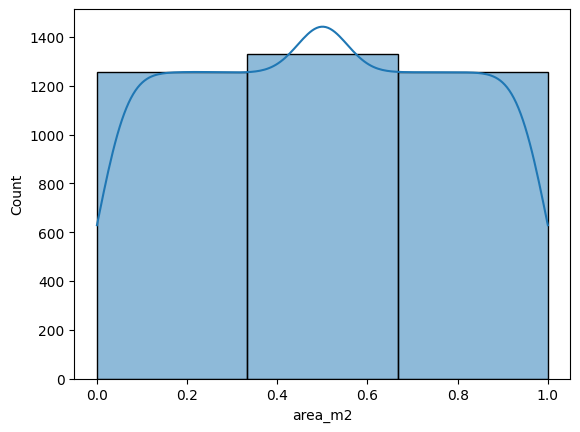

In [120]:
sns.histplot(data=train,bins=3, x='area_m2', kde=True)

<Axes: ylabel='area_m2'>

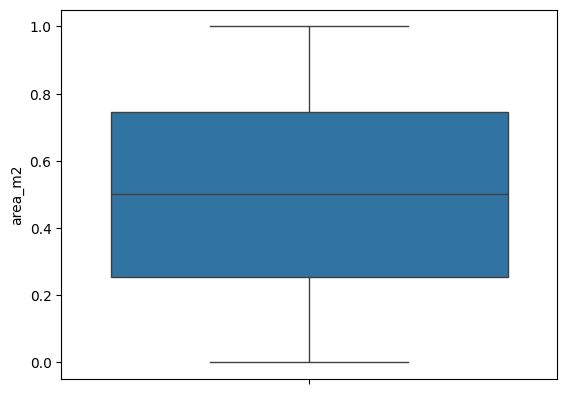

In [121]:
sns.boxplot(train['area_m2'])


**<span style="color:blue;">TRAITEMENT DE 'is_finished_and_fenced'</span>**

In [122]:
def split(df):
    
    df[['is_finished', 'is_fenced']] = df['is_finished_and_fenced'].str.split('/', expand=True)

    is_finished = df['is_finished']
    is_fenced = df['is_fenced']

    df = supprimer_colonnes(df,['is_finished', 'is_fenced', 'is_finished_and_fenced'])

    df.insert(2, 'is_finished', is_finished)
    df.insert(3, 'is_fenced', is_fenced)
 
    return df
l_discret.remove('is_finished_and_fenced')
l_discret.append('is_finished')
l_discret.append('is_fenced')
train = split(train)
test = split(test)
train



,coverage_period,is_residential,is_finished,is_fenced,has_garden,locality,area_m2,structure_type,window_count,claim
0,1.0,1.0,N,V,V,U,0.521522,Wood-framed,without,non
1,1.0,1.0,V,N,O,R,0.914705,Non-combustible,4,oui
2,0.5,0.0,N,V,V,U,0.273273,Wood-framed,without,oui
3,0.5,0.0,N,V,V,U,0.768183,Ordinary,without,non
4,1.0,1.0,V,N,O,R,0.753253,Non-combustible,2,non
...,...,...,...,...,...,...,...,...,...,...
4322,0.5,0.0,N,V,V,U,0.078579,Non-combustible,without,non
4323,0.5,0.0,N,V,V,U,0.022623,Non-combustible,without,non
4324,0.5,0.0,V,N,O,R,0.444444,Fire-resistive,4,non
4325,0.5,0.0,V,N,O,R,0.243341,Fire-resistive,4,non


**<span style="color:blue;">TRAITEMENT DE  'Window_count'</span>**

In [123]:
train['window_count'].value_counts()

window_count
without    1847
4           502
3           442
5           356
2           200
6           188
7           130
8            65
1            43
>=10         41
9            29
Name: count, dtype: int64

In [124]:
def trait_number_windows(df):
    df=df.replace('without',0)
    df=df.replace('>=10',10)
    df['window_count']=df['window_count'].astype('int32')
    return df

train=trait_number_windows(train)
test=trait_number_windows(test)
train['window_count'].value_counts()


window_count
0     1847
4      502
3      442
5      356
2      200
6      188
7      130
8       65
1       43
10      41
9       29
Name: count, dtype: int64

In [125]:
train.isna().sum()

coverage_period    0
is_residential     0
is_finished        0
is_fenced          0
has_garden         0
locality           0
area_m2            0
structure_type     0
window_count       0
claim              0
dtype: int64

In [126]:
train.dtypes

coverage_period    float64
is_residential     float64
is_finished         object
is_fenced           object
has_garden          object
locality            object
area_m2            float64
structure_type      object
window_count         int32
claim               object
dtype: object

In [127]:
print(l_discret)

['coverage_period', 'is_residential', 'has_garden', 'locality', 'structure_type', 'window_count', 'is_finished', 'is_fenced']


**<span style="color:blue;">VISUALISTAION</span>**

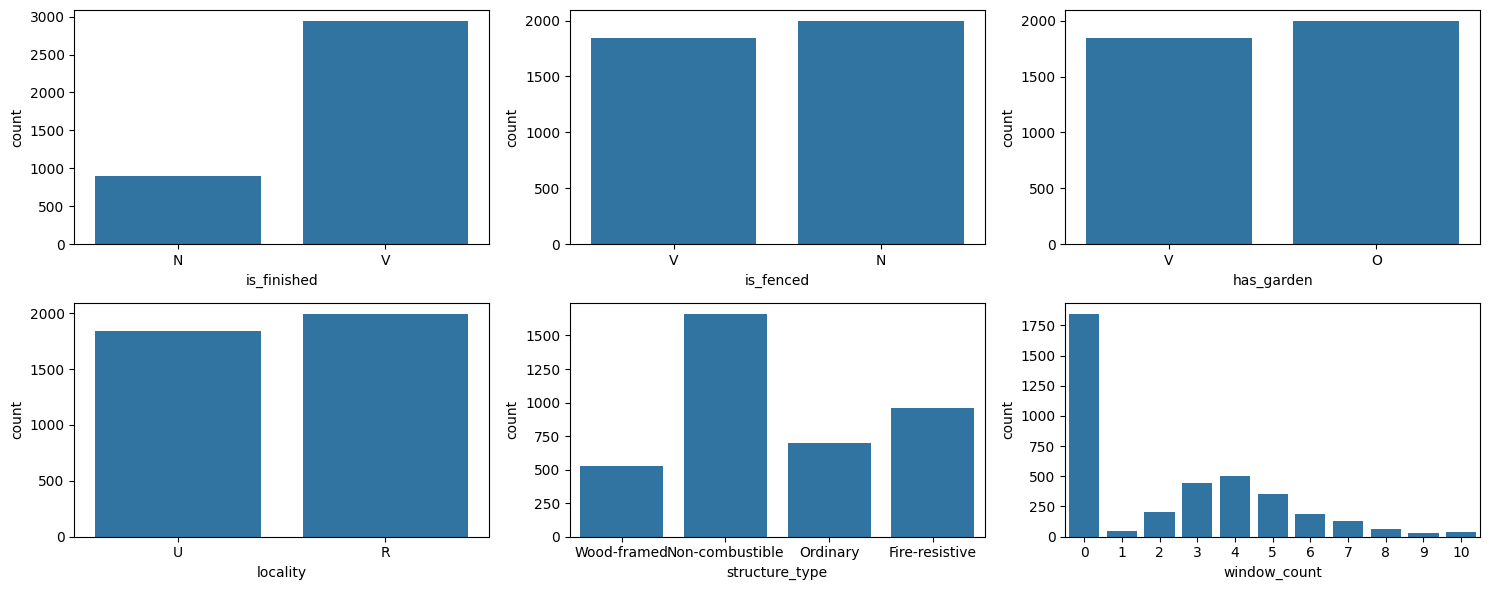

In [128]:
L=[ 'is_finished', 'is_fenced', 'has_garden', 'locality', 'structure_type', 'window_count']
plt.figure(figsize=(15,6))
for i in range(len(L)):
    plt.subplot(2,3,i+1)
    sns.countplot(data=train, x=L[i])
plt.tight_layout()
plt.show()

**<span style="color:blue;">TRANSFORMATION</span>**

In [129]:
train

,coverage_period,is_residential,is_finished,is_fenced,has_garden,locality,area_m2,structure_type,window_count,claim
0,1.0,1.0,N,V,V,U,0.521522,Wood-framed,0,non
1,1.0,1.0,V,N,O,R,0.914705,Non-combustible,4,oui
2,0.5,0.0,N,V,V,U,0.273273,Wood-framed,0,oui
3,0.5,0.0,N,V,V,U,0.768183,Ordinary,0,non
4,1.0,1.0,V,N,O,R,0.753253,Non-combustible,2,non
...,...,...,...,...,...,...,...,...,...,...
4322,0.5,0.0,N,V,V,U,0.078579,Non-combustible,0,non
4323,0.5,0.0,N,V,V,U,0.022623,Non-combustible,0,non
4324,0.5,0.0,V,N,O,R,0.444444,Fire-resistive,4,non
4325,0.5,0.0,V,N,O,R,0.243341,Fire-resistive,4,non


In [130]:
class OneHotencoder:

    def __init__(self, cols):
        self.cols = cols               
        self.enc = OneHotEncoder(sparse_output=False)

    def fit(self, df):
       
        df_sub = df[self.cols]

        self.enc.fit(df_sub)

        
        self.feature_names = self.enc.get_feature_names_out(self.cols)

        return self   

    def transform(self, df):

        df_result = df.copy()

        
        claim_exists = "claim" in df_result.columns
        if claim_exists:
            claim_col = df_result["claim"].copy()

        
        df_sub = df_result[self.cols]

        
        encoded = self.enc.transform(df_sub)

        
        df_encoded = pd.DataFrame(encoded, columns=self.feature_names, index=df.index)

        
        df_result = df_result.drop(columns=self.cols)

        
        df_result = pd.concat([df_result, df_encoded], axis=1)

        
        if claim_exists:
            df_result = df_result.drop(columns=["claim"])
            df_result["claim"] = claim_col

        return df_result

    def fit_transform(self, df):
        self.fit(df)
        return self.transform(df)
    
encoder = OneHotencoder(cols=L)

train = encoder.fit_transform(train)

test = encoder.transform(test)
train

,coverage_period,is_residential,area_m2,is_finished_N,is_finished_V,is_fenced_N,is_fenced_V,has_garden_O,has_garden_V,locality_R,...,window_count_2,window_count_3,window_count_4,window_count_5,window_count_6,window_count_7,window_count_8,window_count_9,window_count_10,claim
0,1.0,1.0,0.521522,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
1,1.0,1.0,0.914705,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,oui
2,0.5,0.0,0.273273,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,oui
3,0.5,0.0,0.768183,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
4,1.0,1.0,0.753253,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4322,0.5,0.0,0.078579,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
4323,0.5,0.0,0.022623,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
4324,0.5,0.0,0.444444,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,non
4325,0.5,0.0,0.243341,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,non


In [131]:
test

,coverage_period,is_residential,area_m2,is_finished_N,is_finished_V,is_fenced_N,is_fenced_V,has_garden_O,has_garden_V,locality_R,...,window_count_2,window_count_3,window_count_4,window_count_5,window_count_6,window_count_7,window_count_8,window_count_9,window_count_10,claim
0,1.0,0,0.856133,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,oui
1,1.0,0,0.575224,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,non
2,1.0,1,0.667500,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,oui
3,1.0,0,0.724627,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,oui
4,0.5,0,0.800517,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,non
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2001,0.5,1,0.393726,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
2002,1.0,0,0.500178,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
2003,1.0,0,0.336837,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,non
2004,1.0,1,0.257889,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,oui


**<span style="color:red;">Partie2:</span>**

In [132]:
X_train=train.iloc[:,:-1]
y_train=train.iloc[:,-1]

X_test=test.iloc[:,:-1]
y_test =test.iloc[:,-1]
def encode_labels_basic(y_train, y_test):
    
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_test_encoded = le.transform(y_test)
    
    return y_train_encoded, y_test_encoded


y_train, y_test= encode_labels_basic(y_train, y_test)

**<span style="color:blue;">Importance des features </span>**

In [133]:

rf = RandomForestClassifier(random_state=42, n_jobs=-1)


param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


gs = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)


gs.fit(X_train, y_train)


print("Meilleurs hyperparamètres :", gs.best_params_)
print("Meilleur score F1-weighted CV :", gs.best_score_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Meilleurs hyperparamètres : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Meilleur score F1-weighted CV : 0.7577519690710425



📊 Feature Importances (Random Forest) :


,Feature,Importance
2,area_m2,0.689836
0,coverage_period,0.045584
1,is_residential,0.040177
14,structure_type_Wood-framed,0.032746
22,window_count_7,0.020396
11,structure_type_Fire-resistive,0.020220
12,structure_type_Non-combustible,0.019053
13,structure_type_Ordinary,0.016559
25,window_count_10,0.015554
20,window_count_5,0.013194


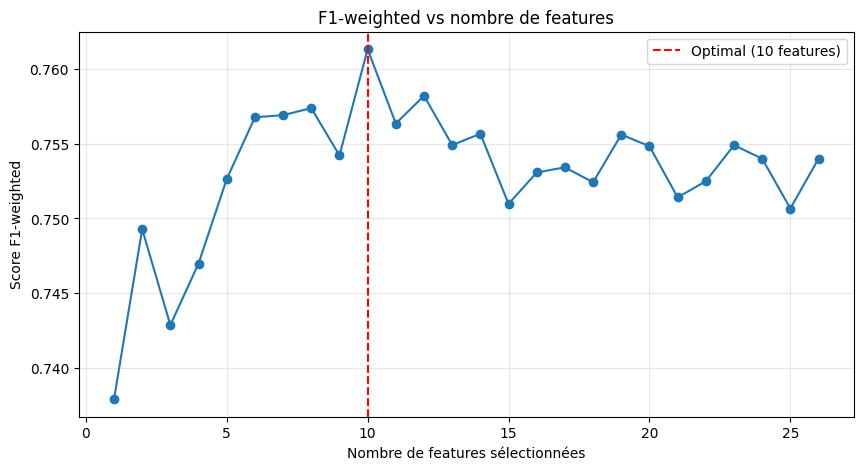

In [134]:
def bestfeatures(X, y, best_rf, cv_splits=5):

    
    importances = best_rf.feature_importances_

    
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    
    print("\n📊 Feature Importances (Random Forest) :")
    display(feature_importance_df)

    
    sorted_features = feature_importance_df['Feature'].values
    scores = []

    
    for n in range(1, len(sorted_features) + 1):
        selected_features = sorted_features[:n]
        X_subset = X[selected_features].values

        score = cross_val_score(
            best_rf,
            X_subset,
            y,
            cv=cv_splits,
            scoring='f1_weighted',
            n_jobs=-1
        ).mean()

        scores.append(score)

    
    best_idx = np.argmax(scores)
    optimal_features = sorted_features[:best_idx + 1]
    best_score = scores[best_idx]

    
    plt.figure(figsize=(10,5))
    plt.plot(range(1, len(sorted_features) + 1), scores, marker='o')
    plt.axvline(x=best_idx + 1, color='r', linestyle='--',
                label=f'Optimal ({best_idx+1} features)')
    plt.xlabel("Nombre de features sélectionnées")
    plt.ylabel("Score F1-weighted")
    plt.title("F1-weighted vs nombre de features")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    

    return feature_importance_df, scores, optimal_features, best_score
best_rf = gs.best_estimator_

feature_importance_df, scores, optimal_features, best_score = bestfeatures(
    X_train, y_train, best_rf
)

In [135]:
X_train_sel = X_train[optimal_features]
X_test_sel = X_test[optimal_features]

In [463]:

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}
rf = RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42
    )

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_weighted",     # ou f1, roc_auc
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_sel, y_train)

print("Best Params :", grid.best_params_)
print("Best Score (CV):", grid.best_score_)



Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best Score (CV): 0.750146601240717


In [464]:
best_model_rf = grid.best_estimator_


best_model_rf.fit(X_train_sel, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=500,
                       random_state=42)

In [ ]:




log_reg = LogisticRegression(max_iter=1000, random_state=42)


param_grid_log = [
    
    {
        'penalty': ['l1'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'saga'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 200, 500]
    },
    
    {
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 200, 500]
    },
    
    {
        'penalty': ['elasticnet'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],  
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 200, 500]
    },
    
    {
        'penalty': [None],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],  
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 200, 500]
    }
]


grid_log = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid_log,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1,
    error_score='raise'  
)

grid_log.fit(X_train_sel, y_train)

print("Best Params Logistic Regression:", grid_log.best_params_)
print("Best Score Logistic Regression (CV):", grid_log.best_score_)


Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best Params Logistic Regression: {'C': 10, 'class_weight': None, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Score Logistic Regression (CV): 0.7471722423161562


In [ ]:
best_model_log = grid_log.best_estimator_


best_model_log.fit(X_train_sel, y_train)

LogisticRegression(C=10, penalty='l1', random_state=42, solver='liblinear')

In [ ]:



dt = DecisionTreeClassifier(random_state=42)


param_grid_dt = {
    'max_depth': [None, 5, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.8],
    'class_weight': [None, 'balanced']
}


grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train_sel, y_train)

print("Best Params Decision Tree:", grid_dt.best_params_)
print("Best Score Decision Tree (CV):", grid_dt.best_score_)


Fitting 5 folds for each of 2400 candidates, totalling 12000 fits
Best Params Decision Tree: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best Score Decision Tree (CV): 0.7618872134163872


In [468]:
best_model_dt = grid_dt.best_estimator_


best_model_dt.fit(X_train_sel, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=20, max_features=0.5,
                       min_samples_leaf=8, min_samples_split=20,
                       random_state=42)

In [469]:



svc_linear = SVC(kernel='linear', random_state=42, class_weight='balanced',probability=True)


param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1],
    'class_weight': [None, 'balanced']
}

# HalvingGridSearchCV 
grid_svc = HalvingGridSearchCV(
    estimator=svc_linear,
    param_grid=param_grid_svm,
    factor=3,                
    scoring='f1_weighted',   
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Recherche rapide avec HalvingGridSearchCV pour SVM...")
grid_svc.fit(X_train_sel, y_train)


print(f"\nBest Params SVC Linear: {grid_svc.best_params_}")
print(f"Best Score SVC Linear (CV): {grid_svc.best_score_}")

Recherche rapide avec HalvingGridSearchCV pour SVM...
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 142
max_resources_: 3843
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 54
n_resources: 142
Fitting 5 folds for each of 54 candidates, totalling 270 fits
----------
iter: 1
n_candidates: 18
n_resources: 426
Fitting 5 folds for each of 18 candidates, totalling 90 fits
----------
iter: 2
n_candidates: 6
n_resources: 1278
Fitting 5 folds for each of 6 candidates, totalling 30 fits
----------
iter: 3
n_candidates: 2
n_resources: 3834
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Best Params SVC Linear: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'poly'}
Best Score SVC Linear (CV): 0.7536541315053279


In [470]:
best_model_svm = grid_svc.best_estimator_


best_model_svm.fit(X_train_sel, y_train)

SVC(C=10, kernel='poly', probability=True, random_state=42)

In [471]:
mlp = MLPClassifier(random_state=42, max_iter=1000)

# Grille d'hyperparamètres
param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50), (100, 100)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate': ['constant', 'invscaling', 'adaptive'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128],
    'max_iter': [500, 1000]
}

# GridSearch


grid_mlp = HalvingGridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,  
    factor=3,                           
    cv=5,
    verbose=3,                          
    n_jobs=-1,
    random_state=42,
    aggressive_elimination=True         
)

print("\n🚀 Démarrage HalvingGridSearchCV...")
print("   Élimine les mauvaises combinaisons tôt!")
grid_mlp.fit(X_train_sel, y_train)

print("Best Params MLP:", grid_mlp.best_params_)
print("Best Score MLP (CV):", grid_mlp.best_score_)



🚀 Démarrage HalvingGridSearchCV...
   Élimine les mauvaises combinaisons tôt!
n_iterations: 9
n_required_iterations: 9
n_possible_iterations: 5
min_resources_: 20
max_resources_: 3843
aggressive_elimination: True
factor: 3
----------
iter: 0
n_candidates: 9720
n_resources: 20
Fitting 5 folds for each of 9720 candidates, totalling 48600 fits
----------
iter: 1
n_candidates: 3240
n_resources: 20
Fitting 5 folds for each of 3240 candidates, totalling 16200 fits
----------
iter: 2
n_candidates: 1080
n_resources: 20
Fitting 5 folds for each of 1080 candidates, totalling 5400 fits
----------
iter: 3
n_candidates: 360
n_resources: 20
Fitting 5 folds for each of 360 candidates, totalling 1800 fits
----------
iter: 4
n_candidates: 120
n_resources: 20
Fitting 5 folds for each of 120 candidates, totalling 600 fits
----------
iter: 5
n_candidates: 40
n_resources: 60
Fitting 5 folds for each of 40 candidates, totalling 200 fits
----------
iter: 6
n_candidates: 14
n_resources: 180
Fitting 5 folds f

In [ ]:
best_model_mlp = grid_mlp.best_estimator_


best_model_mlp.fit(X_train_sel, y_train)

MLPClassifier(activation='logistic', alpha=0.001, batch_size=128,
              hidden_layer_sizes=(50,), max_iter=1000, random_state=42,
              solver='sgd')

In [ ]:
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2],  # pour minkowski (1=manhattan, 2=euclidean)
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}


grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_knn.fit(X_train_sel, y_train)

print("Best Params KNN:", grid_knn.best_params_)
print("Best Score KNN (CV):", grid_knn.best_score_)


Fitting 5 folds for each of 336 candidates, totalling 1680 fits
Best Params KNN: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}
Best Score KNN (CV): 0.36680365748302707


In [ ]:
best_model_knn = grid_knn.best_estimator_

best_model_knn.fit(X_train_sel, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=3, p=1)

In [ ]:
def plot_f1_weighted_train_test(
    models_dict,
    X_train, y_train,
    X_test, y_test
):


    model_names = []
    f1_train_scores = []
    f1_test_scores = []

    for name, model in models_dict.items():
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        f1_train = f1_score(y_train, y_train_pred, average="weighted")
        f1_test = f1_score(y_test, y_test_pred, average="weighted")

        model_names.append(name)
        f1_train_scores.append(f1_train)
        f1_test_scores.append(f1_test)

    x = np.arange(len(model_names))
    width = 0.35

    plt.figure(figsize=(12, 6))
    bars_train = plt.bar(x - width/2, f1_train_scores, width, label="Train")
    bars_test = plt.bar(x + width/2, f1_test_scores, width, label="Test")

    plt.xlabel("Modèles")
    plt.ylabel("F1 weighted")
    plt.title("Comparaison F1 weighted — Train vs Test")
    plt.xticks(x, model_names, rotation=20)
    plt.legend()
    plt.ylim(0, 1.05)

    for bars in [bars_train, bars_test]:
        for bar in bars:
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.3f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

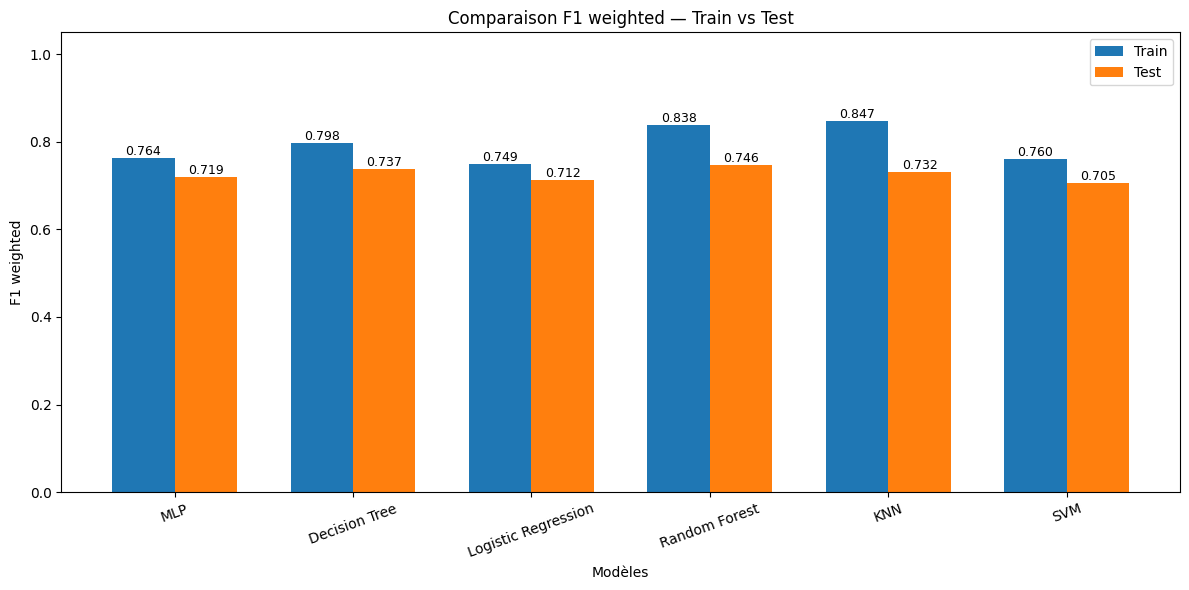

In [ ]:
models = {
    "MLP": best_model_mlp,
    "Decision Tree": best_model_dt,
    "Logistic Regression": best_model_log,
    "Random Forest": best_model_rf,
    "KNN": best_model_knn,
    "SVM": best_model_svm
}

plot_f1_weighted_train_test(models, X_train_sel, y_train, X_test_sel, y_test)

In [478]:
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import StackingClassifier
stack = StackingClassifier(
    estimators=[
        ('rf', best_model_rf),
        ('knn', best_model_knn),
        ('mlp', best_model_mlp)
    ],
    final_estimator=MLPClassifier()
)
stack.fit(X_train_sel, y_train)

StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=10,
                                                       n_estimators=500,
                                                       random_state=42)),
                               ('knn',
                                KNeighborsClassifier(metric='manhattan',
                                                     n_neighbors=3, p=1)),
                               ('mlp',
                                MLPClassifier(activation='logistic',
                                              alpha=0.001, batch_size=128,
                                              hidden_layer_sizes=(50,),
                                              max_iter=1000, random_state=42,
                                              solver='sgd'))],
                   final_estimator=MLPClassifier())

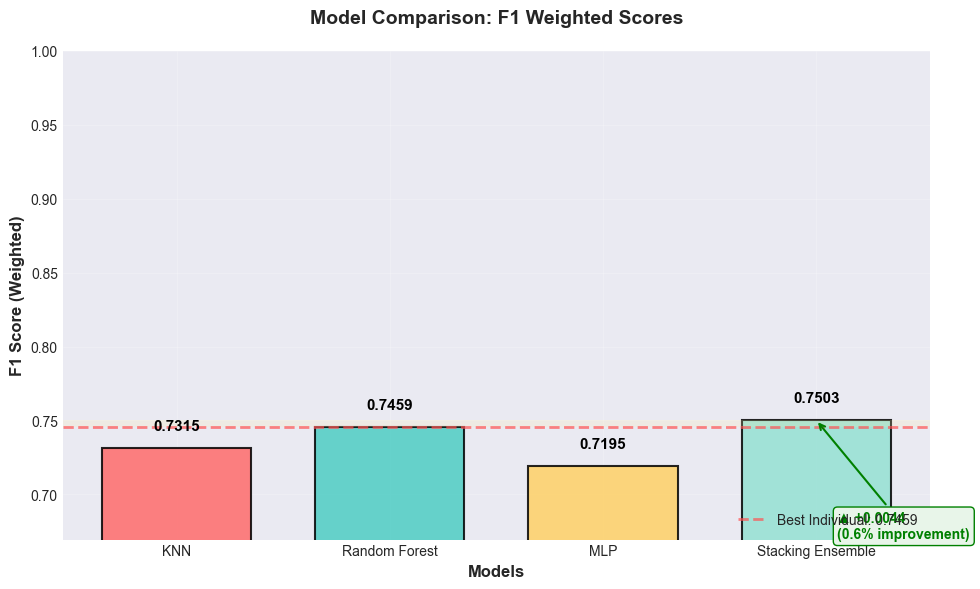


F1 WEIGHTED SCORES COMPARISON
  KNN                  : 0.7315
  Random Forest        : 0.7459
  MLP                  : 0.7195
  Stacking Ensemble    : 0.7503 ★

Best Individual Model  : 0.7459
Stacking Ensemble      : 0.7503
Improvement            : +0.0044 (0.59%)


In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, ax = plt.subplots(figsize=(10, 6))


model_names = ['KNN', 'Random Forest', 'MLP', 'Stacking Ensemble']
models_list = [models['knn'], models['rf'], models['mlp'], stack]

f1_scores = []
for model in models_list:
    y_pred = model.predict(X_test_sel)
    f1 = f1_score(y_test, y_pred, average='weighted')
    f1_scores.append(f1)


colors = ['#FF6B6B', '#4ECDC4', '#FFD166', '#95E1D3']


bars = ax.bar(model_names, f1_scores, color=colors, edgecolor='black', 
              linewidth=1.5, alpha=0.85, width=0.7)


for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{score:.4f}', ha='center', va='bottom', 
            fontsize=11, fontweight='bold', color='black')


best_individual = max(f1_scores[:3])
ax.axhline(y=best_individual, color='#FF5252', linestyle='--', 
           linewidth=2, alpha=0.7, label=f'Best Individual: {best_individual:.4f}')


ax.axhspan(best_individual, f1_scores[3], facecolor='#FFEAA7', alpha=0.2)


ax.set_ylabel('F1 Score (Weighted)', fontsize=12, fontweight='bold')
ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison: F1 Weighted Scores', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim([min(f1_scores) - 0.05, 1.0])


gain = f1_scores[3] - best_individual
if gain > 0:
    ax.annotate(f'▲ +{gain:.4f}\n({(gain/best_individual*100):.1f}% improvement)', 
                xy=(3, f1_scores[3]), xytext=(3.1, f1_scores[3] - 0.08),
                arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                fontsize=10, fontweight='bold', color='green',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8F5E9", edgecolor="green"))

ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)


plt.xticks(fontsize=10, rotation=0)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("F1 WEIGHTED SCORES COMPARISON")
print("="*60)

for name, score in zip(model_names, f1_scores):
    stars = " ★" if score == max(f1_scores) else ""
    print(f"  {name:20} : {score:.4f}{stars}")

print("\n" + "="*60)
print(f"Best Individual Model  : {best_individual:.4f}")
print(f"Stacking Ensemble      : {f1_scores[3]:.4f}")
print(f"Improvement            : +{gain:.4f} ({(gain/best_individual*100):.2f}%)")
print("="*60)

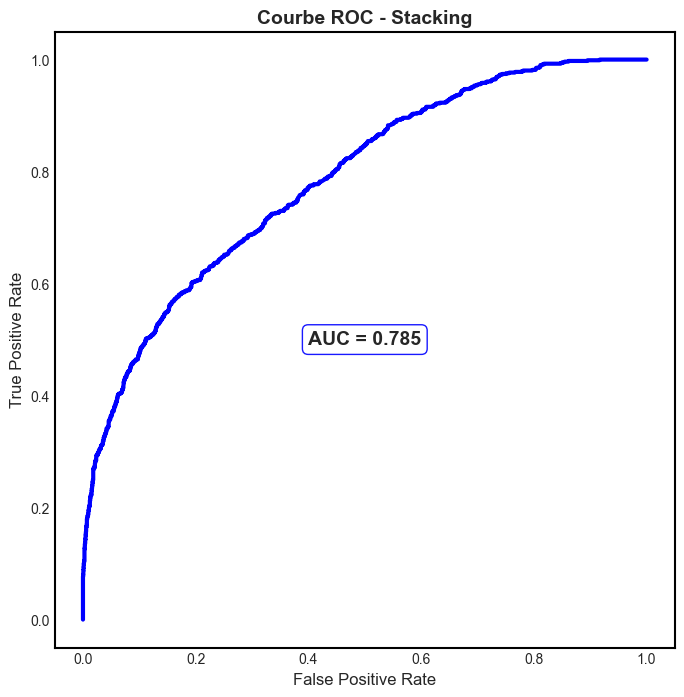

✅ AUC Stacking: 0.7854


In [ ]:
y_proba_stack = stack.predict_proba(X_train_sel)
y_proba_stack = y_proba_stack[:, 1]
fpr, tpr, _ = roc_curve(y_train, y_proba_stack)
roc_auc = auc(fpr, tpr)
    
   
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', lw=3, label=f'stack (AUC = {roc_auc:.3f})')


plt.text(0.5, 0.5, f'AUC = {roc_auc:.3f}', 
             fontsize=14, fontweight='bold', 
             bbox=dict(boxstyle='round', facecolor='white', edgecolor='blue', alpha=0.9),
             horizontalalignment='center', verticalalignment='center')
    
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Courbe ROC - Stacking', fontsize=14, fontweight='bold')
  
    
    
plt.grid(True, color='white', linewidth=1.5)
ax = plt.gca()
ax.set_facecolor('white')
    
  
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)
    
plt.show()
    
print(f"✅ AUC Stacking: {roc_auc:.4f}")

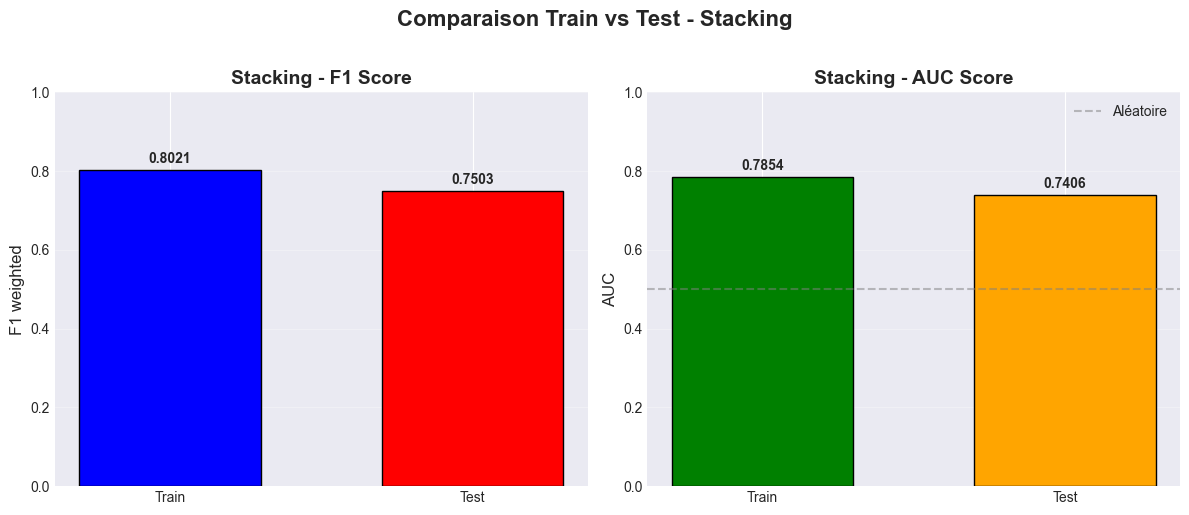

RÉSULTATS STACKING
F1-score Train: 0.8021
F1-score Test:  0.7503
Différence F1:   0.0519
------------------------------
AUC Train:       0.7854
AUC Test:        0.7406
Différence AUC:  0.0448


In [ ]:


def plot_model_comparison(model, X_train, y_train, X_test, y_test, model_name="Modèle"):
   
    
    f1_train = f1_score(y_train, model.predict(X_train), average="weighted")
    f1_test = f1_score(y_test, model.predict(X_test), average="weighted")
    
    
    
    auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    auc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    
    
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    
    bars1 = ax1.bar(["Train", "Test"], [f1_train, f1_test], 
                    color=['blue', 'red'], edgecolor='black', width=0.6)
    ax1.set_title(f'{model_name} - F1 Score', fontsize=14, fontweight='bold')
    ax1.set_ylabel("F1 weighted", fontsize=12)
    ax1.set_ylim(0, 1)
    ax1.grid(True, alpha=0.3, axis='y')
    
    
    for bar in bars1:
        y = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, y + 0.01,
                f"{y:.4f}", ha="center", va="bottom", fontweight='bold')
    
    
    bars2 = ax2.bar(["Train", "Test"], [auc_train, auc_test], 
                    color=['green', 'orange'], edgecolor='black', width=0.6)
    ax2.set_title(f'{model_name} - AUC Score', fontsize=14, fontweight='bold')
    ax2.set_ylabel("AUC", fontsize=12)
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3, axis='y')
    
    
    for bar in bars2:
        y = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, y + 0.01,
                f"{y:.4f}", ha="center", va="bottom", fontweight='bold')
    
    
    ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Aléatoire')
    ax2.legend()
    
    
    plt.suptitle(f'Comparaison Train vs Test - {model_name}', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()
    
   
    return {
        'f1_train': f1_train, 'f1_test': f1_test,
        'auc_train': auc_train, 'auc_test': auc_test
    }


results = plot_model_comparison(
    model=stack,
    X_train=X_train_sel,
    y_train=y_train,
    X_test=X_test_sel,
    y_test=y_test,
    model_name="Stacking"
)

Text(0.5, 1.0, 'Confusion Matrix - Train')

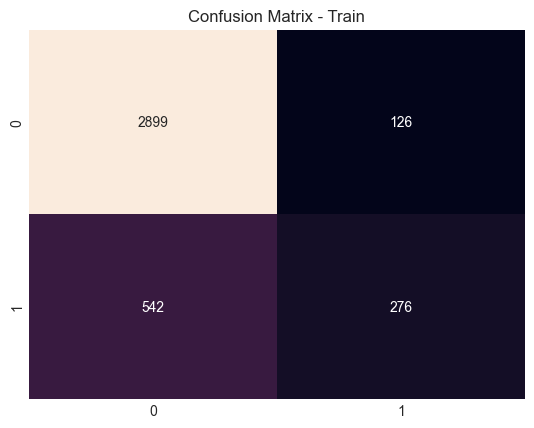

In [ ]:
y_pred_train = stack.predict(X_train_sel)
y_pred_test = stack.predict(X_test_sel)
cm_train = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm_train, annot=True, cbar=False,
xticklabels=stack.classes_, yticklabels=stack.classes_,fmt='d')
plt.title("Confusion Matrix - Train")

Text(0.5, 1.0, 'Confusion Matrix - Test')

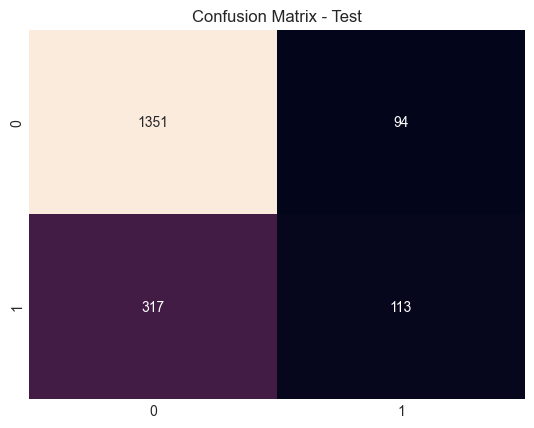

In [ ]:
cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, cbar=False,
xticklabels=stack.classes_, yticklabels=stack.classes_,fmt='d')
plt.title("Confusion Matrix - Test")